###**First just unzipping files/loading data from Google drive zipped folders, and checking data is there**


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import glob
hits = glob.glob('/content/drive/MyDrive/DATASCI 281*/BDD100k DATA')
print(hits)

['/content/drive/MyDrive/DATASCI 281 Group Project/BDD100k DATA']


In [4]:
BASE = hits[0]
!ls -lh "{BASE}"

total 5.5G
-rw------- 1 root root 5.3G Jun 25 02:30 bdd100k_images_100k.zip
-rw------- 1 root root 181M Jun 25 02:40 bdd100k_labels.zip
-rw------- 1 root root 7.9M Jul  8 18:59 scene_manifest.csv


In [5]:
!find /content/data -type f | wc -l


find: ‘/content/data’: No such file or directory
0


In [6]:
#Unzip folder to local disc
!unzip -q "{BASE}/bdd100k_images_100k.zip" -d /content/data


In [7]:
#Check before unzip labels on Google Drive
!ls -R "{BASE}/bdd100k_labels.zip" | head -40

/content/drive/MyDrive/DATASCI 281 Group Project/BDD100k DATA/bdd100k_labels.zip


In [8]:
#Unzip labels folder on Google Drive
!unzip -q "{BASE}/bdd100k_labels.zip" -d /content/data


In [9]:
#Verify
!find /content/data -name "*.json" | head -20


/content/data/100k/val/c3fd58b6-04bcbef3.json
/content/data/100k/val/b3a9281a-74ae5b60.json
/content/data/100k/val/b4ec8b36-e81e510a.json
/content/data/100k/val/bfd64d5f-f98204af.json
/content/data/100k/val/b54fd2cd-829309c7.json
/content/data/100k/val/bd4518ef-d4c1fa7f.json
/content/data/100k/val/b8c60cba-d52cfc92.json
/content/data/100k/val/bf6711ef-76e408aa.json
/content/data/100k/val/b5614611-ae322079.json
/content/data/100k/val/c5f0cacd-3c4333b4.json
/content/data/100k/val/c0e05e70-6431cfed.json
/content/data/100k/val/b1e1a7b8-65ec7612.json
/content/data/100k/val/c91b89eb-bd95cbff.json
/content/data/100k/val/b74111eb-d21a119b.json
/content/data/100k/val/b96d19af-4b6a5a63.json
/content/data/100k/val/bdb95837-2e514e25.json
/content/data/100k/val/c379f9c4-079ee461.json
/content/data/100k/val/b769f2fa-9473432d.json
/content/data/100k/val/b7def2fa-8283e208.json
/content/data/100k/val/c3fdd07a-6a106ecd.json


In [10]:
import glob
imgs = glob.glob('/content/data/**/*.jpg', recursive=True)
print(f"Found {len(imgs)} images")
print(imgs[:3])

Found 100000 images
['/content/data/100k/val/bd08d471-cb9e4be6.jpg', '/content/data/100k/val/ba4a95e2-388b7299.jpg', '/content/data/100k/val/b6f8a510-6f70445f.jpg']


In [11]:
!find /content/data -name "*.json"


Streaming output truncated to the last 5000 lines.
/content/data/100k/test/e140f7b2-c8eb0465.json
/content/data/100k/test/d7c16a51-8f6ccab7.json
/content/data/100k/test/fd42c3de-a46984f8.json
/content/data/100k/test/d0a607b1-37865ffc.json
/content/data/100k/test/f11eac8e-d6357af9.json
/content/data/100k/test/f16c9d4f-87b71ff2.json
/content/data/100k/test/f6127260-e6692e42.json
/content/data/100k/test/f64d9066-cb2d99d7.json
/content/data/100k/test/ecfbd4a8-db7c47b3.json
/content/data/100k/test/e13b5481-51a0da76.json
/content/data/100k/test/e40c95fe-7428492a.json
/content/data/100k/test/cefbbb38-53d3ff82.json
/content/data/100k/test/ec674bc7-5310dc0f.json
/content/data/100k/test/ee7fd7bd-38d309e4.json
/content/data/100k/test/da862f49-237eec9a.json
/content/data/100k/test/f247a833-5144d93d.json
/content/data/100k/test/f36200f2-3d3bf0d8.json
/content/data/100k/test/eb991015-9973b0c5.json
/content/data/100k/test/e41d2210-982e3acd.json
/content/data/100k/test/df33833e-ce3378fb.json
/content/

In [12]:
#seperate labels data from images data into separate folders.

import os, glob, shutil

src_root = '/content/data/100k_images'
dst_root = '/content/data/100k_labels'

moved = 0
for split in ['train', 'val', 'test']:
    src_dir = os.path.join(src_root, split)
    dst_dir = os.path.join(dst_root, split)
    os.makedirs(dst_dir, exist_ok=True)

    for jf in glob.glob(os.path.join(src_dir, '*.json')):
        shutil.move(jf, os.path.join(dst_dir, os.path.basename(jf)))
        moved += 1

print(f"Moved {moved} json files")

Moved 0 json files


In [13]:
import glob
for split in ['train', 'val', 'test']:
    imgs = len(glob.glob(f'/content/data/100k_images/{split}/*.jpg'))
    lbls = len(glob.glob(f'/content/data/100k_labels/{split}/*.json'))
    print(f"{split}: {imgs} images, {lbls} labels")

train: 0 images, 0 labels
val: 0 images, 0 labels
test: 0 images, 0 labels


###Second, develop feature extraction

In [15]:
#Diagnose split error after switching to T4 GPU run time for processing
!ls /content/data/
!find /content/data -name "*.json" | head -5
!find /content/data -name "*.json" | wc -l


100k  100k_labels
/content/data/100k/val/c3fd58b6-04bcbef3.json
/content/data/100k/val/b3a9281a-74ae5b60.json
/content/data/100k/val/b4ec8b36-e81e510a.json
/content/data/100k/val/bfd64d5f-f98204af.json
/content/data/100k/val/b54fd2cd-829309c7.json
100000


In [16]:
import os
os.rename('/content/data/100k', '/content/data/100k_images')

In [17]:
import glob
for split in ['train', 'val', 'test']:
    imgs = len(glob.glob(f'/content/data/100k_images/{split}/*.jpg'))
    lbls = len(glob.glob(f'/content/data/100k_labels/{split}/*.json'))
    print(f"{split}: {imgs} images, {lbls} labels")

train: 70000 images, 0 labels
val: 10000 images, 0 labels
test: 20000 images, 0 labels


In [19]:
!find /content/data -name "*.json" | head -3
!find /content/data -name "*.json" | wc -l

/content/data/100k_images/val/c3fd58b6-04bcbef3.json
/content/data/100k_images/val/b3a9281a-74ae5b60.json
/content/data/100k_images/val/b4ec8b36-e81e510a.json
100000


In [20]:
import os, glob, shutil

for split in ['train', 'val', 'test']:
    dst_dir = f'/content/data/100k_labels/{split}'
    os.makedirs(dst_dir, exist_ok=True)
    for jf in glob.glob(f'/content/data/100k_images/{split}/*.json'):
        shutil.move(jf, os.path.join(dst_dir, os.path.basename(jf)))

for split in ['train', 'val', 'test']:
    imgs = len(glob.glob(f'/content/data/100k_images/{split}/*.jpg'))
    lbls = len(glob.glob(f'/content/data/100k_labels/{split}/*.json'))
    print(f"{split}: {imgs} images, {lbls} labels")

train: 70000 images, 70000 labels
val: 10000 images, 10000 labels
test: 20000 images, 20000 labels


In [21]:
import json, glob, os
import pandas as pd

rows = []
for split in ['train', 'val']:   # test has no scene labels we can use
    for jf in glob.glob(f'/content/data/100k_labels/{split}/*.json'):
        with open(jf) as f:
            d = json.load(f)
        attrs = d.get('attributes', {})
        rows.append({
            'name': os.path.basename(jf).replace('.json', ''),
            'split': split,
            'scene': attrs.get('scene', 'undefined'),
            'weather': attrs.get('weather', 'undefined'),
            'timeofday': attrs.get('timeofday', 'undefined'),
        })

df = pd.DataFrame(rows)
df['img_path'] = '/content/data/100k_images/' + df['split'] + '/' + df['name'] + '.jpg'
df = df[df['scene'] != 'undefined'].reset_index(drop=True)   # drop undefined per proposal

print(df['scene'].value_counts())
df.to_csv(f'{BASE}/scene_manifest.csv', index=False)   # cache to Drive so you never re-parse 80k JSONs

scene
city street     49693
highway         19913
residential      9358
parking lot       427
tunnel            156
gas stations       34
Name: count, dtype: int64


In [22]:
CAP = 1200   # per-class cap for the dev subset

sample = (df.groupby('scene', group_keys=False)
            .apply(lambda g: g.sample(min(len(g), CAP), random_state=42))
            .reset_index(drop=True))
print(sample['scene'].value_counts())

scene
city street     1200
highway         1200
residential     1200
parking lot      427
tunnel           156
gas stations      34
Name: count, dtype: int64


/tmp/ipykernel_621/603032773.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), CAP), random_state=42))


In [23]:
import numpy as np
import cv2
from skimage.feature import hog, local_binary_pattern

IMG_W, IMG_H = 256, 144   # keep 16:9, small enough to be fast

def load_img(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, (IMG_W, IMG_H))

def feat_hsv_regions(img, bins=16):
    """Simple feature 1: HSV histograms over top/middle/bottom bands."""
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    h = img.shape[0]
    bands = [hsv[:h//3], hsv[h//3:2*h//3], hsv[2*h//3:]]
    feats = []
    for band in bands:
        for ch in range(3):
            hist = cv2.calcHist([band], [ch], None, [bins], [0, 256]).flatten()
            feats.append(hist / (hist.sum() + 1e-8))
    return np.concatenate(feats)          # 3 bands × 3 ch × 16 bins = 144 dims

def feat_hog(img):
    """Simple feature 2: HOG on grayscale."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return hog(gray, orientations=9, pixels_per_cell=(16, 16),
               cells_per_block=(2, 2), feature_vector=True)

def feat_lbp(img, P=8, R=1):
    """Simple feature 3: uniform LBP histogram."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    lbp = local_binary_pattern(gray, P, R, method='uniform')
    hist, _ = np.histogram(lbp, bins=P+2, range=(0, P+2))
    return hist / (hist.sum() + 1e-8)

In [24]:
import torch, torchvision
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import Dataset, DataLoader

device = 'cuda' if torch.cuda.is_available() else 'cpu'
weights = ResNet50_Weights.IMAGENET1K_V2
model = resnet50(weights=weights)
model.fc = torch.nn.Identity()          # 2048-dim penultimate embeddings
model = model.eval().to(device)
preprocess = weights.transforms()

class ImgDS(Dataset):
    def __init__(self, paths): self.paths = paths
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = load_img(self.paths[i])
        return preprocess(torch.from_numpy(img).permute(2,0,1))

@torch.no_grad()
def extract_resnet(paths, bs=64):
    dl = DataLoader(ImgDS(paths), batch_size=bs, num_workers=2)
    out = [model(b.to(device)).cpu().numpy() for b in dl]
    return np.vstack(out)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 155MB/s]


In [25]:
import torch
print(torch.cuda.is_available())

True


In [26]:
from tqdm import tqdm #this part is much faster after switching to T4 GPU

hsv_f, hog_f, lbp_f = [], [], []
for p in tqdm(sample['img_path']):
    img = load_img(p)
    hsv_f.append(feat_hsv_regions(img))
    hog_f.append(feat_hog(img))
    lbp_f.append(feat_lbp(img))

X_hsv, X_hog, X_lbp = map(np.array, (hsv_f, hog_f, lbp_f))
X_resnet = extract_resnet(sample['img_path'].tolist())
y = sample['scene'].values

np.savez(f'{BASE}/features_dev.npz', hsv=X_hsv, hog=X_hog,
         lbp=X_lbp, resnet=X_resnet, y=y)   # cache to Drive — extraction is the slow part

100%|██████████| 4217/4217 [01:29<00:00, 47.27it/s]


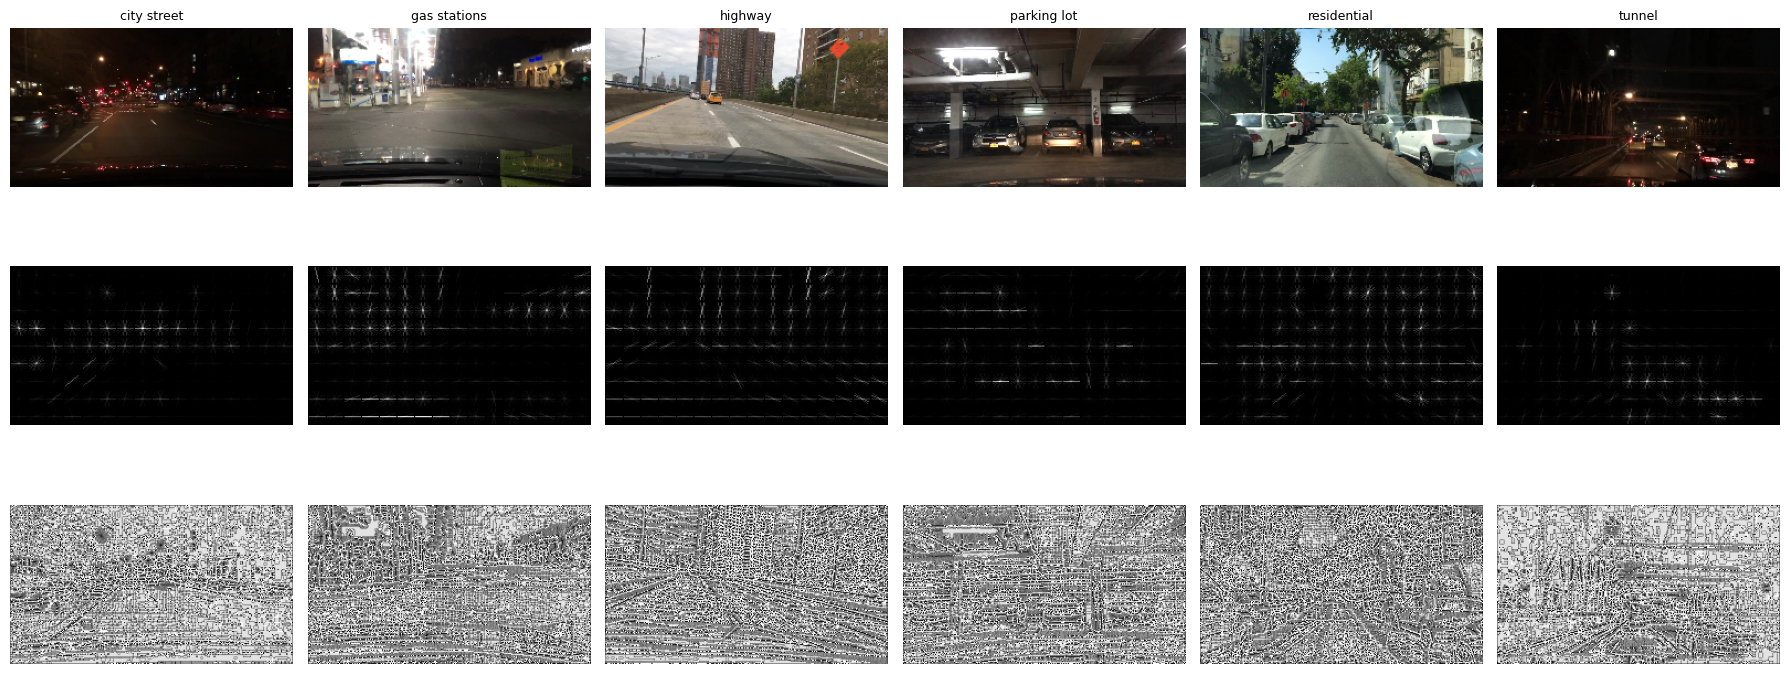

In [27]:
#Illustrations

import matplotlib.pyplot as plt
from skimage.feature import hog as hog_vis

classes = sorted(sample['scene'].unique())
fig, axes = plt.subplots(3, len(classes), figsize=(3*len(classes), 8))
for j, c in enumerate(classes):
    p = sample[sample['scene'] == c]['img_path'].iloc[0]
    img = load_img(p)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, hog_img = hog_vis(gray, orientations=9, pixels_per_cell=(16,16),
                         cells_per_block=(2,2), visualize=True)
    lbp = local_binary_pattern(gray, 8, 1, method='uniform')
    axes[0, j].imshow(img);              axes[0, j].set_title(c, fontsize=9)
    axes[1, j].imshow(hog_img, cmap='gray')
    axes[2, j].imshow(lbp, cmap='gray')
    for i in range(3): axes[i, j].axis('off')
axes[0,0].set_ylabel('Original'); axes[1,0].set_ylabel('HOG'); axes[2,0].set_ylabel('LBP')
plt.tight_layout(); plt.show()

100%|██████████| 4217/4217 [00:19<00:00, 217.84it/s]


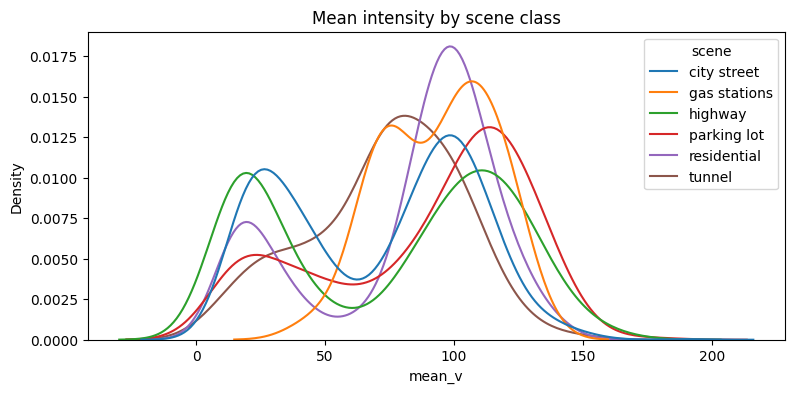

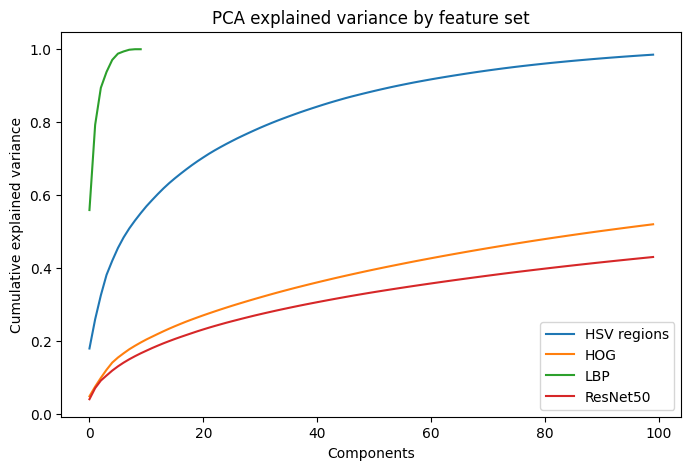

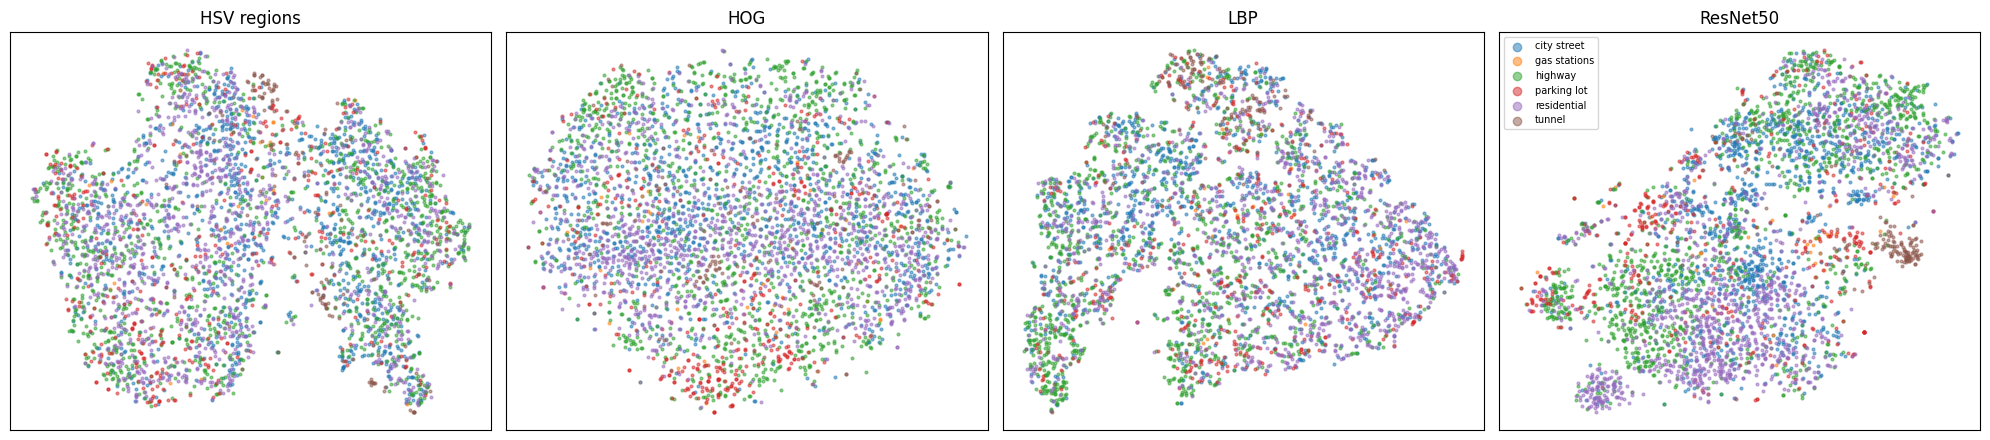

In [28]:
#Variation plots, PCA, t-SNE

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Variation: e.g. mean brightness (V channel) by class — tunnels should pop out dark
sample['mean_v'] = [load_img(p)[:,:,:].mean() for p in tqdm(sample['img_path'])]
plt.figure(figsize=(9,4))
sns.kdeplot(data=sample, x='mean_v', hue='scene', common_norm=False)
plt.title('Mean intensity by scene class'); plt.show()

feature_sets = {'HSV regions': X_hsv, 'HOG': X_hog, 'LBP': X_lbp, 'ResNet50': X_resnet}

# PCA explained variance per feature set
plt.figure(figsize=(8,5))
for name, X in feature_sets.items():
    Xs = StandardScaler().fit_transform(X)
    pca = PCA(n_components=min(100, X.shape[1])).fit(Xs)
    plt.plot(np.cumsum(pca.explained_variance_ratio_), label=name)
plt.xlabel('Components'); plt.ylabel('Cumulative explained variance')
plt.legend(); plt.title('PCA explained variance by feature set'); plt.show()

# t-SNE per feature set (PCA-reduce first for speed)
fig, axes = plt.subplots(1, len(feature_sets), figsize=(5*len(feature_sets), 4.5))
for ax, (name, X) in zip(axes, feature_sets.items()):
    Xs = StandardScaler().fit_transform(X)
    Xp = PCA(n_components=min(50, X.shape[1])).fit_transform(Xs)
    emb = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(Xp)
    for c in classes:
        m = y == c
        ax.scatter(emb[m,0], emb[m,1], s=4, alpha=0.5, label=c)
    ax.set_title(name); ax.set_xticks([]); ax.set_yticks([])
axes[-1].legend(markerscale=3, fontsize=7)
plt.tight_layout(); plt.show()

# Feature Extraction: Methods, Rationale, and Preliminary Results

## Why these features

Scene classification is a *holistic* recognition problem: the identity of a driving environment lives in global layout, color composition, and texture statistics rather than in any single object. Per our proposal, we selected features that each target a distinct physical signature of the scene classes, plus one learned representation as a benchmark:

| Feature | Type | Dims | What it captures |
|---|---|---|---|
| **Region-wise HSV histograms** | Simple | 144 | Color distribution over top/middle/bottom bands — the sky–structure–road stratification. Highways carry a large low-saturation sky band; tunnels are globally dark with concentrated artificial-light hues; residential frames show green vegetation mid-frame. |
| **Histogram of Oriented Gradients (HOG)** | Simple | 4,320 | Edge density and orientation. City streets are edge-dense with strong vertical building/signage edges; highways are sparser with long converging lane lines. |
| **Local Binary Patterns (LBP)** | Simple | 10 | Micro-texture — separates smooth asphalt, foliage, and building facades. Nearly free to compute, giving us an efficiency-side baseline for the accuracy-vs-cost analysis. |
| **ResNet50 embeddings** | Complex | 2,048 | Penultimate-layer activations of an ImageNet-pretrained CNN — a learned semantic representation against which the hand-crafted features are benchmarked. |

All features are extracted from frames downscaled to 256×144 (preserving BDD's 16:9 aspect ratio) for computational efficiency.

## Data preparation

We built a manifest by parsing the per-image label JSONs for the train and val splits, extracting each image's `scene`, `weather`, and `timeofday` attributes and dropping `undefined` scene tags per the proposal. The **verified class counts** (replacing the proposal's Table 1 estimates) are: city street 49,693 · highway 19,913 · residential 9,358 · parking lot 427 · tunnel 156 · gas stations 34 — a total of 79,581 labeled frames with a ~1,460:1 imbalance between the dominant and rarest class.

For feature development we use a **stratified dev subsample of 4,217 images**: the three common classes are capped at 1,200 images each, while *every* image from the three rare classes is retained. This keeps iteration fast while preserving the maximum available signal for rare classes.

## Results and interpretation

**Feature illustrations.** The per-class visualization grid confirms the intended behavior: HOG renders city street frames as dense vertical edge fields while highway frames reduce to sparse converging lane geometry; LBP maps show clearly different texture statistics for road surface, vegetation, and built structure.

**Dataset variation.** The mean-intensity KDE by class shows pronounced **day/night bimodality** within most classes — consistent with BDD's balanced day/night capture — and confirms tunnel frames concentrate at low intensity. This exposes a confound we will carry into interpretation: intensity/color features partially encode *timeofday* rather than *scene*. (A follow-up t-SNE recolored by `timeofday` will quantify this.)

**PCA decomposition.** Cumulative explained-variance curves reveal very different intrinsic dimensionality across feature sets. LBP (10-D) and the HSV region histograms saturate within a few dozen components; HOG spreads variance thinly across thousands of dimensions and is the prime candidate for PCA reduction before classification; ResNet embeddings show a steep initial rise followed by a long informative tail.

**t-SNE visualization.** The headline preliminary finding: **ResNet50 embeddings produce visibly tighter, better-separated class clusters than any hand-crafted feature**, with highway and city street forming distinct regions. The simple features show partial, diffuse structure — real signal, but heavy class overlap. This mirrors both reference projects, where pretrained embeddings drove the decisive accuracy improvement. Notably, the rare classes (gas stations n=34, tunnel n=156, parking lot n=427) do not form coherent islands in *any* feature space — concrete evidence supporting our proposal's contingency of class weighting and/or merging rare classes into an "other" category before classifier training.

## Implications for classification

1. Class imbalance is confirmed and severe → macro-averaged F1 and confusion matrices (not raw accuracy), with class weighting or resampling.
2. ResNet embeddings will anchor the accuracy-optimized solution; HSV+LBP offer a cheap feature stack for the efficiency-optimized solution required by the rubric.
3. PCA to ~50 components is justified for HOG and the concatenated feature stack before training.
